# Spatial autocorrelation of NAFLD Kendall tau on the core network (posonly distances)

Global (Moran's I) and local (LISA) spatial autocorrelation of the NAFLD-tested
metabolites' weighted Kendall tau values, using the *core* correlation network's
`posonly` graph distances (positive-edges-only, dijkstra distance = 1 - r) as the
spatial structure. No filtering: every core-graph node that has a tau value is
included.


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib import pyplot as plt

from utils.path import find_root

ROOT = find_root()
CORE_GRAPH_DIR = ROOT / "checkpoints" / "metabolomics_workbench" / "core_graph"
NAFLD_SUBGRAPH_DIR = ROOT / "checkpoints" / "metabolomics_workbench" / "nafld_subgraph"

rng = np.random.default_rng(0)


## Load core-graph posonly distances and NAFLD tau values

In [2]:
D_full = pd.read_csv(CORE_GRAPH_DIR / "graph_distances_posonly.csv", index_col=0)
print("core graph (posonly) nodes:", D_full.shape[0])

tau_full = pd.read_parquet(NAFLD_SUBGRAPH_DIR / "nodes.parquet").set_index("node_id")["nafld_kendall_tau"]
print("NAFLD-tested metabolites (weighted tau):", len(tau_full))

# Any core-graph node that has a tau value -- no other filtering.
nodes = D_full.index.intersection(tau_full.index)
print("nodes with both a core-graph posonly distance and a tau value:", len(nodes))

D = D_full.loc[nodes, nodes]
tau = tau_full.loc[nodes]

assert np.isfinite(D.values).all(), "posonly distance matrix has non-finite entries for the selected nodes"


core graph (posonly) nodes: 4429
NAFLD-tested metabolites (weighted tau): 1375
nodes with both a core-graph posonly distance and a tau value: 1375


## Spatial weights from graph distance

Inverse-distance weights (`w_ij = 1/d_ij`, `i != j`), row-standardized, so each
node's spatial lag is a weighted average of its (graph-)neighbors' tau, with
closer nodes (smaller posonly distance) weighted more heavily.

In [3]:
n = len(nodes)
Dv = D.values.astype(float)
np.fill_diagonal(Dv, 0)  # kill self-weight
W = (1 - Dv)**2
row_sums = W.sum(axis=1, keepdims=True)
W_std = W / row_sums  # row-standardized

x = tau.values.astype(float)
z = x - x.mean()


## Global Moran's I

$$I = \frac{n}{S_0} \cdot \frac{z^\top W z}{z^\top z}, \qquad S_0 = \sum_{i,j} w_{ij}$$

Significance via permutation (random reassignment of tau values to nodes,
keeping the network/weights fixed).

In [4]:
def global_moran(z, W_std):
    n = len(z)
    S0 = W_std.sum()
    num = z @ (W_std @ z)
    den = z @ z
    return (n / S0) * (num / den)


def global_moran_test(x, W_std, n_perm=999, rng=None):
    rng = rng or np.random.default_rng()
    z = x - x.mean()
    I_obs = global_moran(z, W_std)

    n = len(x)
    perm_I = np.empty(n_perm)
    for k in range(n_perm):
        xp = rng.permutation(x)
        zp = xp - xp.mean()
        perm_I[k] = global_moran(zp, W_std)

    mean_perm, sd_perm = perm_I.mean(), perm_I.std(ddof=1)
    z_score = (I_obs - mean_perm) / sd_perm
    p_value = (np.sum(np.abs(perm_I - mean_perm) >= np.abs(I_obs - mean_perm)) + 1) / (n_perm + 1)
    return I_obs, z_score, p_value, perm_I


N_PERM = 9999

I_obs, z_score, p_value, perm_I = global_moran_test(x, W_std, n_perm=N_PERM, rng=rng)
print(f"Global Moran's I = {I_obs:.4f}")
print(f"expected I under CSR (~-1/(n-1)) = {-1 / (n - 1):.4f}")
print(f"permutation z-score = {z_score:.3f}, p-value = {p_value:.4g}  (n_perm={N_PERM})")


Global Moran's I = 0.0721
expected I under CSR (~-1/(n-1)) = -0.0007
permutation z-score = 56.611, p-value = 0.0001  (n_perm=9999)


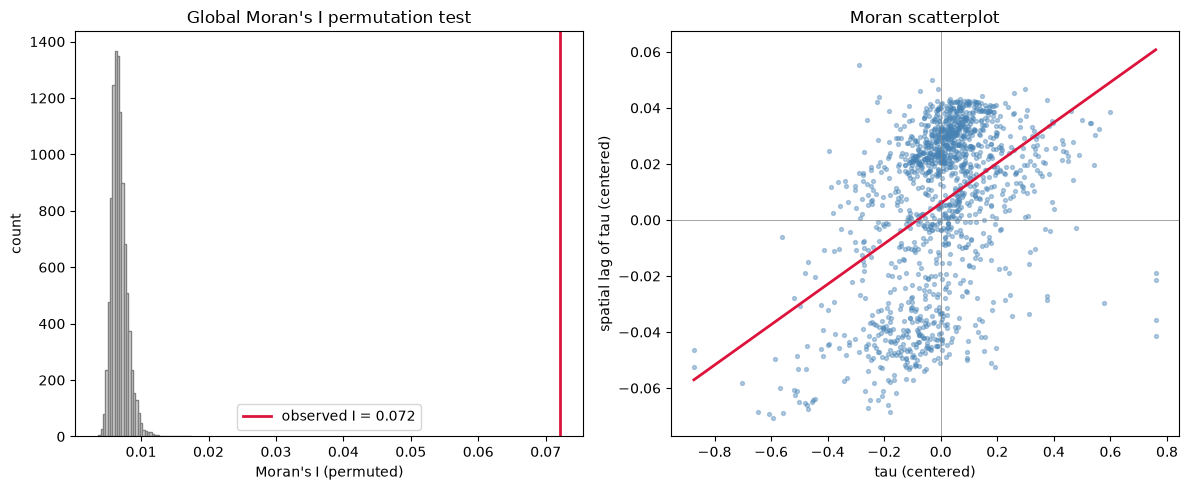

In [5]:
def plot_global_moran(I_obs, perm_I, z, W_std, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].hist(perm_I, bins=40, color="lightgrey", edgecolor="grey")
    axes[0].axvline(I_obs, color="crimson", lw=2, label=f"observed I = {I_obs:.3f}")
    axes[0].set_xlabel("Moran's I (permuted)")
    axes[0].set_ylabel("count")
    axes[0].set_title(f"Global Moran's I permutation test{title_suffix}")
    axes[0].legend()

    lag = W_std @ z
    slope, intercept, r, p, se = stats.linregress(z, lag)
    xs = np.linspace(z.min(), z.max(), 100)
    axes[1].scatter(z, lag, s=8, alpha=0.4, color="steelblue")
    axes[1].plot(xs, intercept + slope * xs, color="crimson", lw=2)
    axes[1].axhline(0, color="grey", lw=0.5)
    axes[1].axvline(0, color="grey", lw=0.5)
    axes[1].set_xlabel("tau (centered)")
    axes[1].set_ylabel("spatial lag of tau (centered)")
    axes[1].set_title(f"Moran scatterplot{title_suffix}")

    fig.tight_layout()
    plt.show()


plot_global_moran(I_obs, perm_I, z, W_std)


## Local Moran's I (LISA)

$$I_i = \frac{z_i}{m_2} \sum_j w_{ij} z_j, \qquad m_2 = \frac{1}{n}\sum_i z_i^2$$

Significance again via conditional permutation per node (tau values of all
*other* nodes reshuffled, node $i$'s own value held fixed), which is the
standard LISA inference approach.

In [9]:
def local_moran(z, W_std):
    m2 = (z ** 2).mean()
    lag = W_std @ z
    return (z / m2) * lag


def local_moran_test(x, W_std, n_perm=999, rng=None):
    # Conditional permutation: node i's own (centered) value z_i stays fixed as
    # the multiplier; only the spatial-lag term is computed from a shuffled
    # copy of the other nodes' values. Since W_std has a zero diagonal, a
    # single full permutation per replicate can be reused for every node's lag
    # in one matrix-vector product -- whatever lands on position i is zeroed
    # out by w_ii=0, so this is equivalent to permuting only the other n-1
    # values for each i, without an O(n_perm * n) python loop.
    rng = rng or np.random.default_rng()
    n = len(x)
    z = x - x.mean()
    m2 = (z ** 2).mean()
    I_local = local_moran(z, W_std)

    perm_I = np.empty((n_perm, n))
    for k in range(n_perm):
        zp = rng.permutation(z)
        lag_perm = W_std @ zp
        perm_I[k] = (z / m2) * lag_perm

    mean_perm = perm_I.mean(axis=0)
    sd_perm = perm_I.std(axis=0, ddof=1)
    z_scores = (I_local - mean_perm) / sd_perm
    p_values = (np.sum(np.abs(perm_I - mean_perm) >= np.abs(I_local - mean_perm), axis=0) + 1) / (n_perm + 1)
    return I_local, z_scores, p_values


def run_lisa(x, W_std, nodes, n_perm=N_PERM, rng=None):
    z = x - x.mean()
    I_local, local_z, local_p = local_moran_test(x, W_std, n_perm=n_perm, rng=rng)

    lag = W_std @ z
    quadrant = np.where(
        (z >= 0) & (lag >= 0), "HH",
        np.where((z < 0) & (lag < 0), "LL",
        np.where((z >= 0) & (lag < 0), "HL", "LH")),
    )

    # simultaneous per-node tests -- correct with Benjamini-Hochberg FDR rather
    # than reading the raw permutation p-values at face value.
    q_values = multipletests(local_p, method="fdr_bh")[1]

    lisa = pd.DataFrame({
        "tau": x,
        "local_I": I_local,
        "z_score": local_z,
        "p_value": local_p,
        "q_value": q_values,
        "quadrant": quadrant,
    }, index=nodes)
    lisa["significant"] = lisa["q_value"] < 0.05
    return lisa


lisa = run_lisa(x, W_std, nodes, n_perm=N_PERM, rng=rng)
print(lisa["significant"].sum(), "/", len(lisa), "nodes significant at q<0.05 (BH-FDR)")
lisa.loc[lisa["significant"]].groupby("quadrant").size()


1110 / 1375 nodes significant at q<0.05 (BH-FDR)


quadrant
HH    501
HL     79
LH    265
LL    265
dtype: int64

In [10]:
lisa.sort_values("local_I", ascending=False).head(15)


,tau,local_I,z_score,p_value,q_value,quadrant,significant
RM0134783,-0.816497,1.425472,7.204382,0.0001,0.000168,LL,True
RM0052754,-0.590248,1.378232,10.287865,0.0001,0.000168,LL,True
RM0033106,-0.550789,1.310471,10.193158,0.0001,0.000168,LL,True
RM0134476,-0.538381,1.308301,10.984337,0.0001,0.000168,LL,True
RM0051673,-0.644658,1.272153,9.477508,0.0001,0.000168,LL,True
RM0054420,-0.816497,1.263252,7.294914,0.0001,0.000168,LL,True
RM0053383,-0.501606,1.193159,10.671254,0.0001,0.000168,LL,True
RM0053637,-0.512973,1.060493,9.663026,0.0001,0.000168,LL,True
RM0033149,-0.446512,1.018543,10.129237,0.0001,0.000168,LL,True
RM0052322,-0.458717,1.002599,10.220996,0.0001,0.000168,LL,True


## LISA cluster map (TSNE layout of the NAFLD subgraph, posonly)

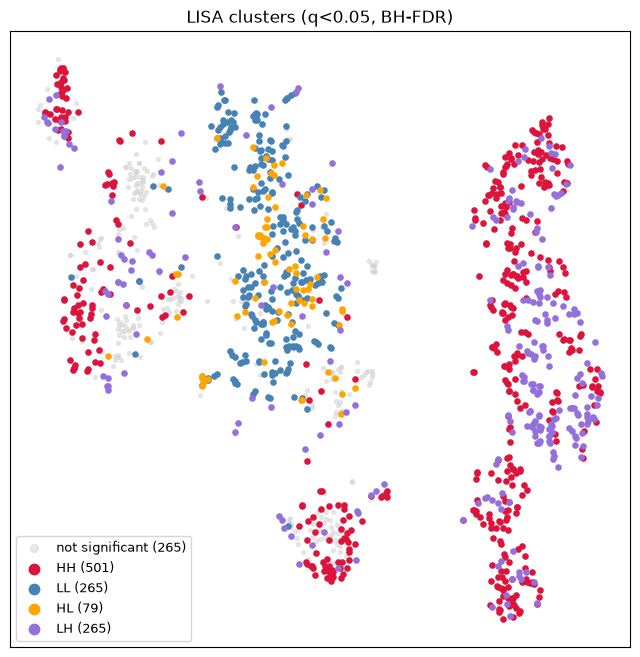

In [11]:
embedding = pd.read_csv(NAFLD_SUBGRAPH_DIR / "embedding_posonly.csv", index_col=0)

colors = {"HH": "crimson", "LL": "steelblue", "HL": "orange", "LH": "mediumpurple"}


def plot_lisa_map(lisa_df, embedding, title_suffix=""):
    plot_df = lisa_df.join(embedding, how="left")

    fig, ax = plt.subplots(figsize=(8, 8))
    not_sig = ~plot_df["significant"]
    ax.scatter(plot_df.loc[not_sig, "x"], plot_df.loc[not_sig, "y"],
               s=8, color="lightgrey", alpha=0.5, label=f"not significant ({not_sig.sum()})")
    for q, color in colors.items():
        sel = plot_df["significant"] & (plot_df["quadrant"] == q)
        ax.scatter(plot_df.loc[sel, "x"], plot_df.loc[sel, "y"],
                   s=14, color=color, label=f"{q} ({sel.sum()})")

    ax.set_title(f"LISA clusters (q<0.05, BH-FDR){title_suffix}")
    ax.legend(markerscale=2, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()


plot_lisa_map(lisa, embedding)


# KNN binary weights

Same nodes and same core-graph `posonly` distances, but the spatial weight
matrix is now built from a k-nearest-neighbor graph instead of full
inverse-distance weighting: `w_ij = 1` if `j` is among `i`'s `k` nearest
neighbors (by posonly graph distance), else `0`, then row-standardized (so
each node's lag is the unweighted average of its k nearest neighbors' tau --
the usual way KNN weights are used for Moran's I). This ignores how close
those neighbors are and how far everyone else is, only *rank* matters.

In [12]:
K = 10

order = np.argsort(Dv, axis=1)  # Dv has +inf on the diagonal, so self never ranks first
knn_idx = order[:, :K]

W_knn = np.zeros_like(Dv)
rows = np.repeat(np.arange(n), K)
W_knn[rows, knn_idx.ravel()] = 1.0
W_knn_std = W_knn / W_knn.sum(axis=1, keepdims=True)  # each row sums to K -> 1/K per neighbor


Global Moran's I (KNN, k=10) = 0.4343
expected I under CSR (~-1/(n-1)) = -0.0007
permutation z-score = 33.885, p-value = 0.0001  (n_perm=9999)


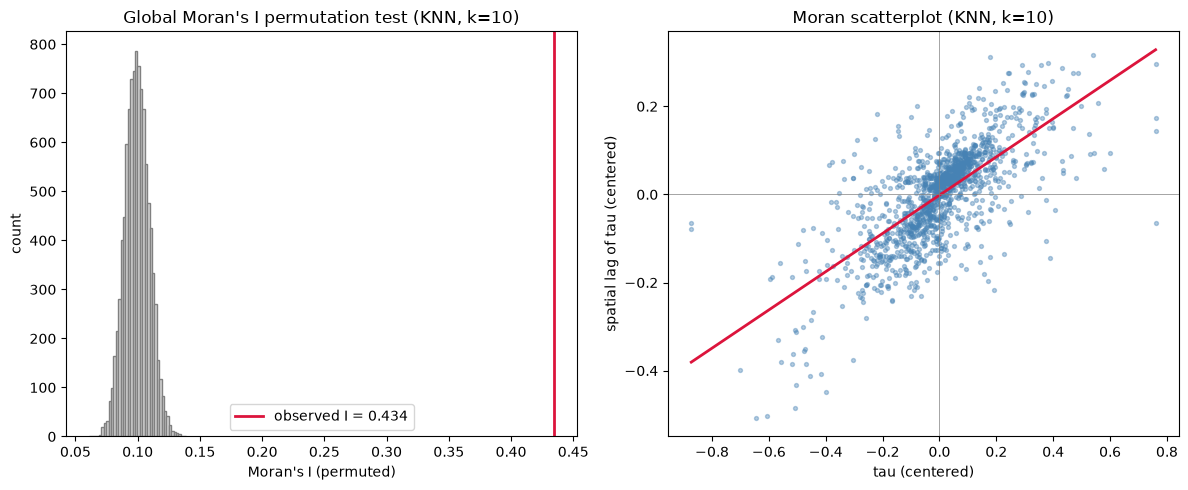

In [13]:
I_obs_knn, z_score_knn, p_value_knn, perm_I_knn = global_moran_test(x, W_knn_std, n_perm=N_PERM, rng=rng)
print(f"Global Moran's I (KNN, k={K}) = {I_obs_knn:.4f}")
print(f"expected I under CSR (~-1/(n-1)) = {-1 / (n - 1):.4f}")
print(f"permutation z-score = {z_score_knn:.3f}, p-value = {p_value_knn:.4g}  (n_perm={N_PERM})")

plot_global_moran(I_obs_knn, perm_I_knn, z, W_knn_std, title_suffix=f" (KNN, k={K})")


In [14]:
lisa_knn = run_lisa(x, W_knn_std, nodes, n_perm=N_PERM, rng=rng)
print(lisa_knn["significant"].sum(), "/", len(lisa_knn), "nodes significant at q<0.05 (BH-FDR)")
lisa_knn.loc[lisa_knn["significant"]].groupby("quadrant").size()


176 / 1375 nodes significant at q<0.05 (BH-FDR)


quadrant
HH    76
HL     5
LH     3
LL    92
dtype: int64

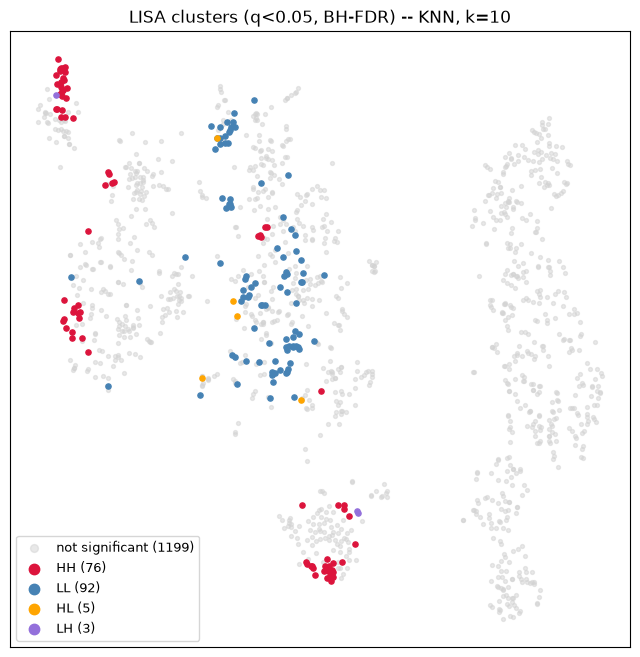

In [15]:
plot_lisa_map(lisa_knn, embedding, title_suffix=f" -- KNN, k={K}")


## Global Moran's I as a function of K

Observed (non-permuted) global Moran's I only, no significance test, swept
over `k = 1..100` KNN neighbors.

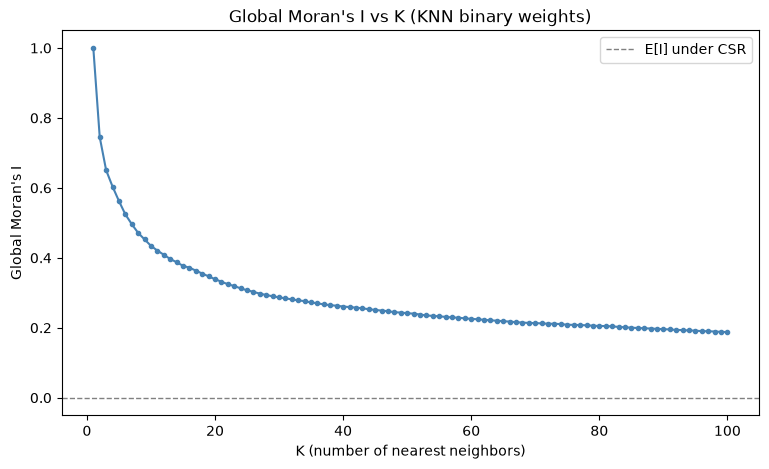

In [16]:
k_values = np.arange(1, 101)
I_by_k = np.empty(len(k_values))

for i, k in enumerate(k_values):
    idx_k = order[:, :k]
    Wk = np.zeros_like(Dv)
    Wk[np.repeat(np.arange(n), k), idx_k.ravel()] = 1.0
    Wk_std = Wk / Wk.sum(axis=1, keepdims=True)
    I_by_k[i] = global_moran(z, Wk_std)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, I_by_k, color="steelblue", marker="o", markersize=3)
ax.axhline(-1 / (n - 1), color="grey", lw=1, ls="--", label="E[I] under CSR")
ax.set_xlabel("K (number of nearest neighbors)")
ax.set_ylabel("Global Moran's I")
ax.set_title("Global Moran's I vs K (KNN binary weights)")
ax.legend()
plt.show()


## Local Moran significance ratio vs K

For each K, fraction of nodes that come out significant (q<0.05, BH-FDR) as
positively autocorrelated (quadrant HH or LL, local I > 0) vs negatively
autocorrelated / spatial outliers (quadrant HL or LH, local I < 0). Uses a
lower permutation count than the main analysis since it repeats the full LISA
permutation test at 100 different K's.

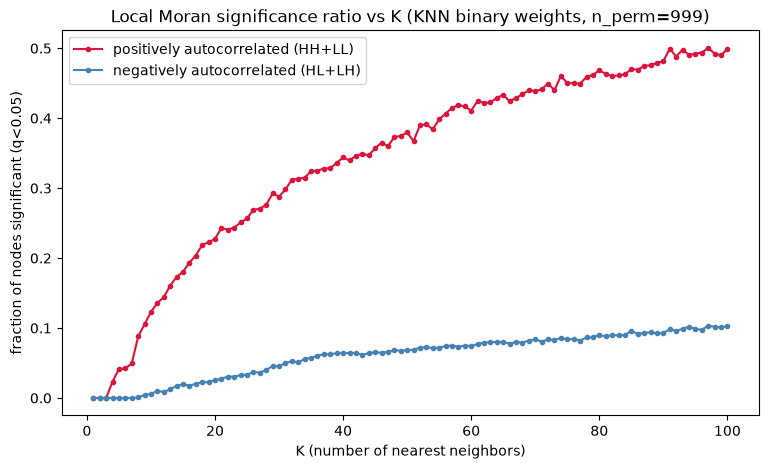

In [17]:
N_PERM_SWEEP = 999

pos_ratio = np.empty(len(k_values))
neg_ratio = np.empty(len(k_values))

for i, k in enumerate(k_values):
    idx_k = order[:, :k]
    Wk = np.zeros_like(Dv)
    Wk[np.repeat(np.arange(n), k), idx_k.ravel()] = 1.0
    Wk_std = Wk / Wk.sum(axis=1, keepdims=True)

    lisa_k = run_lisa(x, Wk_std, nodes, n_perm=N_PERM_SWEEP, rng=rng)
    sig = lisa_k["significant"]
    pos_ratio[i] = (sig & (lisa_k["local_I"] > 0)).mean()
    neg_ratio[i] = (sig & (lisa_k["local_I"] < 0)).mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, pos_ratio, color="crimson", marker="o", markersize=3, label="positively autocorrelated (HH+LL)")
ax.plot(k_values, neg_ratio, color="steelblue", marker="o", markersize=3, label="negatively autocorrelated (HL+LH)")
ax.set_xlabel("K (number of nearest neighbors)")
ax.set_ylabel("fraction of nodes significant (q<0.05)")
ax.set_title(f"Local Moran significance ratio vs K (KNN binary weights, n_perm={N_PERM_SWEEP})")
ax.legend()
plt.show()


# KEGG pathway enrichment: vanilla vs. network-informed pooled tau

Same per-study idea (Wilcoxon rank-sum per KEGG pathway on tau, no cutoff,
own study as background), but here on the *pooled* NAFLD tau -- the
sample-size-weighted Kendall tau aggregated across all NAFLD studies, i.e.
the same `tau` used for the Moran's I / LISA analysis above -- to see whether
aggregating all datasets together, and then denoising against the core
network, improves on plain metabolite-per-metabolite enrichment with no
network information at all.

"Vanilla" = `kegg_wilcoxon` directly on the raw pooled tau. "Network-informed"
= the same random-walk-Laplacian smoothing step used in the per-study
notebook (`(1-lam)*tau + lam*D^-1 A @ tau`, `A` = core graph's direct
posonly-edge weights restricted to these 1375 nodes), with `lam` chosen by a
sweep exactly as before, before running the same Wilcoxon test.

In [18]:
import sys

sys.path.insert(0, str(ROOT / "src"))

import sspa
from mwnetwork import config
from mwnetwork.kegg_enrichment import kegg_wilcoxon, exclude_disease_pathways

refmet_to_kegg = pd.read_csv(config.REFMET_CSV_PATH, index_col="refmet_id")["kegg_id"]
pathways = sspa.process_kegg(organism="hsa")
pathways = exclude_disease_pathways(pathways)
print("KEGG pathways available (disease pathways excluded):", len(pathways))


/anaconda3/envs/metaboenv/lib/python3.14/site-packages/sspa/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


KEGG pathways available (disease pathways excluded): 211


## Vanilla enrichment (raw pooled tau, no network info)

In [19]:
kegg_ids = refmet_to_kegg.reindex(tau.index)
quant_raw = pd.Series(tau.values, index=kegg_ids.values).dropna()
quant_raw = quant_raw.groupby(level=0).mean()  # multiple refmet_id -> same kegg_id
print(f"{len(quant_raw)}/{len(tau)} pooled metabolites mapped to a KEGG ID")

results_raw = kegg_wilcoxon(quant_raw, pathways=pathways, min_pathway_size=2)
sig_raw = results_raw.query("padj < 0.05").sort_values("padj")
print(f"{len(results_raw)} pathway(s) tested, {len(sig_raw)} significant (padj<0.05)")
sig_raw[["pathway_id", "pathway_name", "n_pathway", "n_background", "pval", "padj", "median_in", "median_out"]]


221/1375 pooled metabolites mapped to a KEGG ID
110 pathway(s) tested, 0 significant (padj<0.05)


,pathway_id,pathway_name,n_pathway,n_background,pval,padj,median_in,median_out


## Network-informed enrichment (RW-Laplacian-smoothed pooled tau)

Same smoothing operator as the per-study notebook: build the weighted
adjacency `A` from the core graph's direct posonly edges restricted to these
1375 nodes, then blend each node's tau with its neighbor average,
`(1-lam)*tau + lam*(D^-1 A)@tau`. `lam=0` is the vanilla case above, `lam=1`
fully replaces each tau with its neighbor average. Sweep `lam` to find the
step size that maximizes significant KEGG hits, as before (a full step
oversmoothed in the per-study runs too).

In [20]:
from scipy import sparse

edges = pd.read_parquet(CORE_GRAPH_DIR / "edges.parquet")
edges_pos = edges.loc[edges["r"] > 0, ["source", "target", "weight"]]
print("posonly direct edges (whole core graph):", len(edges_pos))


def rw_laplacian_smooth(tau_series, edges_pos, lam=1.0, transform=None):
    """lam step of random-walk-Laplacian diffusion: (I - lam*L) @ tau
    = (1-lam)*tau + lam*(D^-1 A)@tau, on the subgraph induced by tau's own
    index. Nodes with degree 0 keep their raw tau unchanged."""
    idx_nodes = tau_series.index
    idx = {node: i for i, node in enumerate(idx_nodes)}
    n_nodes = len(idx_nodes)

    e = edges_pos[edges_pos["source"].isin(idx) & edges_pos["target"].isin(idx)]
    rows = e["source"].map(idx).to_numpy()
    cols = e["target"].map(idx).to_numpy()
    w = e["weight"].to_numpy()

    A = sparse.coo_matrix((w, (rows, cols)), shape=(n_nodes, n_nodes))
    if transform is not None:
        A.data = transform(A.data)
    A = (A + A.T).tocsr()  # edges stored once per unordered pair -- symmetrize

    xv = tau_series.to_numpy(dtype=float)
    degree = np.asarray(A.sum(axis=1)).ravel()
    has_neighbors = degree > 0

    x_smooth = xv.copy()
    neighbor_avg = (A[has_neighbors] @ xv) / degree[has_neighbors]
    x_smooth[has_neighbors] = (1 - lam) * xv[has_neighbors] + lam * neighbor_avg

    return pd.Series(x_smooth, index=idx_nodes), has_neighbors.sum(), n_nodes


posonly direct edges (whole core graph): 793065


lam=0.0  significant pathway hits=0
lam=0.1  significant pathway hits=0
lam=0.2  significant pathway hits=0
lam=0.3  significant pathway hits=0
lam=0.4  significant pathway hits=0
lam=0.5  significant pathway hits=0
lam=0.6  significant pathway hits=0
lam=0.7  significant pathway hits=0
lam=0.8  significant pathway hits=0
lam=0.9  significant pathway hits=0
lam=1.0  significant pathway hits=2
lam=1.1  significant pathway hits=2
lam=1.2  significant pathway hits=3
lam=1.3  significant pathway hits=0
lam=1.4  significant pathway hits=0
lam=1.5  significant pathway hits=0
lam=1.6  significant pathway hits=0
lam=1.7  significant pathway hits=0
lam=1.8  significant pathway hits=0
lam=1.9  significant pathway hits=0
lam=2.0  significant pathway hits=0


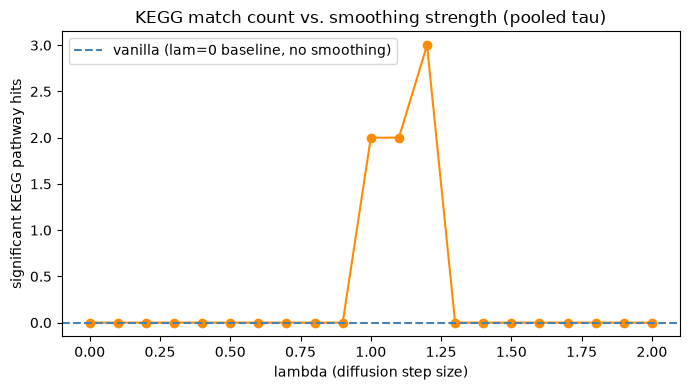

chosen lambda (argmax): 1.2000000000000002


In [21]:
lam_grid = np.linspace(0.0, 2.0, 21)  # 0.0, 0.1, ..., 2.0
n_sig_by_lam = []

for lam in lam_grid:
    tau_smooth, _, _ = rw_laplacian_smooth(tau, edges_pos, lam=lam, transform=lambda w: w**2)
    kegg_ids_s = refmet_to_kegg.reindex(tau_smooth.index)
    quant_s = pd.Series(tau_smooth.values, index=kegg_ids_s.values).dropna().groupby(level=0).mean()

    results_s = kegg_wilcoxon(quant_s, pathways=pathways, min_pathway_size=2)
    n_sig = (results_s["padj"] < 0.05).sum()
    n_sig_by_lam.append(n_sig)
    print(f"lam={lam:.1f}  significant pathway hits={n_sig}")

n_sig_by_lam = np.array(n_sig_by_lam)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lam_grid, n_sig_by_lam, marker="o", color="darkorange")
ax.axhline(len(sig_raw), color="steelblue", ls="--", label="vanilla (lam=0 baseline, no smoothing)")
ax.set_xlabel("lambda (diffusion step size)")
ax.set_ylabel("significant KEGG pathway hits")
ax.set_title("KEGG match count vs. smoothing strength (pooled tau)")
ax.legend()
fig.tight_layout()
plt.show()

LAM = float(lam_grid[np.argmax(n_sig_by_lam)])
print("chosen lambda (argmax):", LAM)


In [22]:
tau_smooth, n_with_neighbors, n_total = rw_laplacian_smooth(tau, edges_pos, lam=LAM, transform=lambda w: w**2)
print(f"{n_with_neighbors}/{n_total} nodes smoothed against >=1 neighbor")

kegg_ids_smooth = refmet_to_kegg.reindex(tau_smooth.index)
quant_smooth = pd.Series(tau_smooth.values, index=kegg_ids_smooth.values).dropna()
quant_smooth = quant_smooth.groupby(level=0).mean()
print(f"{len(quant_smooth)}/{len(tau_smooth)} pooled metabolites mapped to a KEGG ID")

results_smooth = kegg_wilcoxon(quant_smooth, pathways=pathways, min_pathway_size=2)
sig_smooth = results_smooth.query("padj < 0.05").sort_values("padj")
print(f"{len(results_smooth)} pathway(s) tested, {len(sig_smooth)} significant (padj<0.05)")
sig_smooth[["pathway_id", "pathway_name", "n_pathway", "n_background", "pval", "padj", "median_in", "median_out"]]


1375/1375 nodes smoothed against >=1 neighbor
221/1375 pooled metabolites mapped to a KEGG ID
110 pathway(s) tested, 3 significant (padj<0.05)


,pathway_id,pathway_name,n_pathway,n_background,pval,padj,median_in,median_out
0,hsa00590,Arachidonic acid metabolism - Homo sapiens (hu...,19,221,0.000291,0.031986,0.137473,0.072522
1,hsa00970,Aminoacyl-tRNA biosynthesis - Homo sapiens (hu...,21,221,0.000801,0.042851,0.042074,0.081938
2,hsa00500,Starch and sucrose metabolism - Homo sapiens (...,7,221,0.001169,0.042851,0.200697,0.074631


## Vanilla vs. network-informed: which pathways changed

vanilla: 0 significant pathway(s)
network-informed (lam=1.2): 3 significant pathway(s)
kept: []
gained: ['hsa00500', 'hsa00590', 'hsa00970']
lost: []


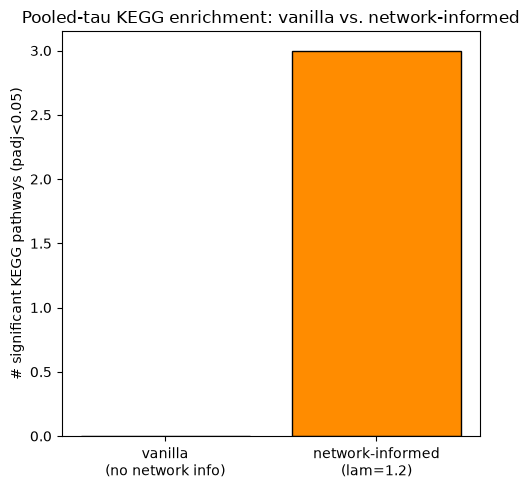

In [23]:
raw_hits = set(sig_raw["pathway_id"])
smooth_hits = set(sig_smooth["pathway_id"])
gained = smooth_hits - raw_hits
lost = raw_hits - smooth_hits
kept = raw_hits & smooth_hits

print(f"vanilla: {len(raw_hits)} significant pathway(s)")
print(f"network-informed (lam={LAM:.1f}): {len(smooth_hits)} significant pathway(s)")
print(f"kept: {sorted(kept)}")
print(f"gained: {sorted(gained)}")
print(f"lost: {sorted(lost)}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(["vanilla\n(no network info)", f"network-informed\n(lam={LAM:.1f})"],
       [len(raw_hits), len(smooth_hits)], color=["steelblue", "darkorange"], edgecolor="black")
ax.set_ylabel("# significant KEGG pathways (padj<0.05)")
ax.set_title("Pooled-tau KEGG enrichment: vanilla vs. network-informed")
fig.tight_layout()
plt.show()


In [24]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=results_raw.statistic,
    y=results_smooth.loc[results_raw.index, "statistic"],
    mode='markers',
    name='Data', # add overing label for the data points: pathway_name
    hovertext=results_raw.pathway_name,
))
fig.update_layout(
    title="Comparison of raw and smoothed statistics",
    xaxis_title="Raw statistic",
    yaxis_title="Smoothed statistic"
)
fig.show()

In [45]:
known_pathways = pd.Index([
    "hsa00061",
    "hsa00071",
    "hsa01212",
    "hsa01040",
    "hsa00561",
    "hsa00564",
    "hsa00600",
    "hsa04071",
    "hsa04979",
    "hsa00100",
    "hsa00120",
    "hsa04976",
    "hsa00590",
    "hsa00591",
    "hsa00480",
    "hsa00270",
    "hsa00260",
    "hsa00280",
    "hsa00010",
    "hsa00020",
    "hsa00620",
    "hsa00190",
    "hsa00051",
    "hsa04923",
    "hsa04152",
    "hsa04150",
    "hsa04068",
    "hsa04922",
])
known_pathways

Index(['hsa00061', 'hsa00071', 'hsa01212', 'hsa01040', 'hsa00561', 'hsa00564',
       'hsa00600', 'hsa04071', 'hsa04979', 'hsa00100', 'hsa00120', 'hsa04976',
       'hsa00590', 'hsa00591', 'hsa00480', 'hsa00270', 'hsa00260', 'hsa00280',
       'hsa00010', 'hsa00020', 'hsa00620', 'hsa00190', 'hsa00051', 'hsa04923',
       'hsa04152', 'hsa04150', 'hsa04068', 'hsa04922'],
      dtype='str')

In [46]:
unknown_pathways = results_raw.loc[~results_raw.pathway_id.isin(known_pathways), "pathway_id"]
unknown_pathways

1      hsa00040
5      hsa00030
7      hsa00053
8      hsa04217
9      hsa00052
         ...   
103    hsa04750
104    hsa00760
107    hsa04625
108    hsa04924
109    hsa00140
Name: pathway_id, Length: 82, dtype: str

In [48]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=results_raw.set_index("pathway_id").loc[known_pathways, "statistic"],
    y=results_smooth.set_index("pathway_id").loc[known_pathways, "statistic"],
    mode='markers',
    name='Data', # add overing label for the data points: pathway_name
    hovertext=results_raw.loc[results_raw.index, "pathway_name"],
))

fig.add_trace(go.Scatter(
    x=results_raw.set_index("pathway_id").loc[unknown_pathways, "statistic"],
    y=results_smooth.set_index("pathway_id").loc[unknown_pathways, "statistic"],
    mode='markers',
    name='Data', # add overing label for the data points: pathway_name
    hovertext=results_raw.loc[results_raw.index, "pathway_name"],
))


fig.update_layout(
    title="Comparison of raw and smoothed statistics",
    xaxis_title="Raw statistic",
    yaxis_title="Smoothed statistic"
)
fig.show()

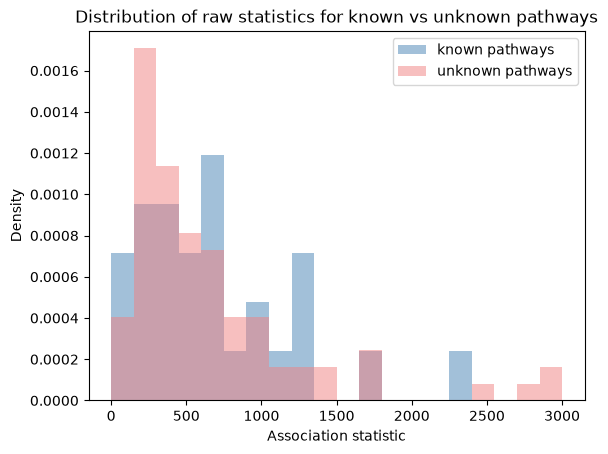

In [57]:
plt.hist(results_raw.set_index("pathway_id").loc[known_pathways, "statistic"], alpha=0.5, color="steelblue", label="known pathways", density=True, bins=np.linspace(0, 3000, 21))
plt.hist(results_raw.set_index("pathway_id").loc[unknown_pathways, "statistic"], alpha=0.5, color="lightcoral", label="unknown pathways", density=True, bins=np.linspace(0, 3000, 21))
plt.xlabel("Association statistic")
plt.ylabel("Density")
plt.legend()
plt.title("Distribution of raw statistics for known vs unknown pathways")
plt.show()

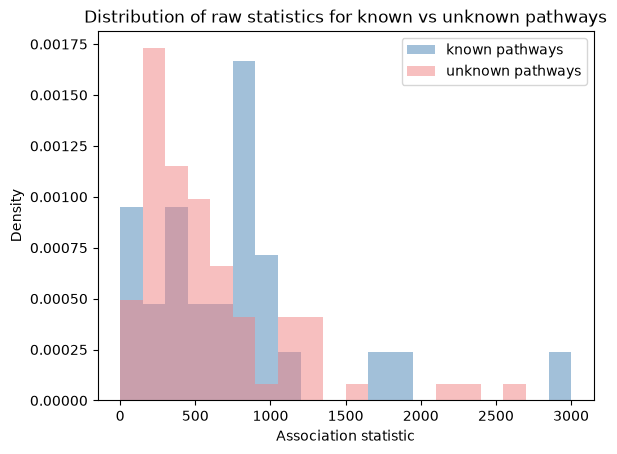

In [58]:
plt.hist(results_smooth.set_index("pathway_id").loc[known_pathways, "statistic"], alpha=0.5, color="steelblue", label="known pathways", density=True, bins=np.linspace(0, 3000, 21))
plt.hist(results_smooth.set_index("pathway_id").loc[unknown_pathways, "statistic"], alpha=0.5, color="lightcoral", label="unknown pathways", density=True, bins=np.linspace(0, 3000, 21))
plt.xlabel("Association statistic")
plt.ylabel("Density")
plt.legend()
plt.title("Distribution of raw statistics for known vs unknown pathways")
plt.show()

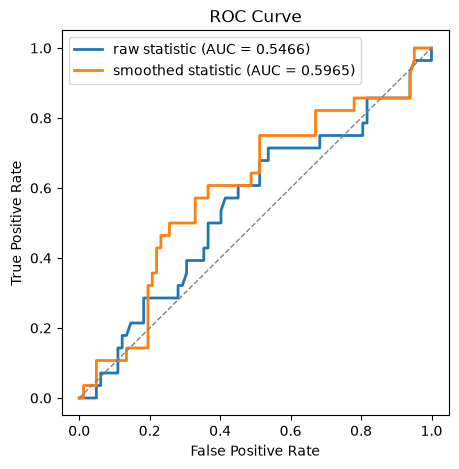

In [69]:
from sklearn.metrics import roc_auc_score, roc_curve

plt.figure(figsize=(5, 5))

fpr, tpr, thresholds = roc_curve(
    results_raw.pathway_id.isin(known_pathways).astype(int),
    results_raw.statistic
)
roc_auc = roc_auc_score(
    results_raw.pathway_id.isin(known_pathways).astype(int),
    results_raw.statistic)
plt.plot(fpr, tpr, lw=2, label="raw statistic (AUC = {:.4f})".format(roc_auc))


fpr, tpr, thresholds = roc_curve(
    results_smooth.pathway_id.isin(known_pathways).astype(int),
    results_smooth.statistic
)
roc_auc = roc_auc_score(
    results_smooth.pathway_id.isin(known_pathways).astype(int),
    results_smooth.statistic)
plt.plot(fpr, tpr, lw=2, label="smoothed statistic (AUC = {:.4f})".format(roc_auc))

plt.plot([0, 1], [0, 1], color="grey", lw=1, ls="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()


In [71]:
from scipy.stats import mannwhitneyu
mannwhitneyu(
    results_raw.set_index("pathway_id").loc[known_pathways, "statistic"],
    results_raw.set_index("pathway_id").loc[unknown_pathways, "statistic"],
    alternative="greater"
)

MannwhitneyuResult(statistic=np.float64(1255.0), pvalue=np.float64(0.2324490829869622))

In [ ]:
mannwhitneyu(
    results_smooth.set_index("pathway_id").loc[known_pathways, "statistic"],
    results_smooth.set_index("pathway_id").loc[unknown_pathways, "statistic"],
    alternative="greater"
)

MannwhitneyuResult(statistic=np.float64(1369.5), pvalue=np.float64(0.06469825517035876))